In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("titanic.csv")

In [3]:
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [4]:
df['age'].fillna(df['age']).mean(),

(np.float64(29.69911764705882),)

In [5]:
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [6]:
df.dropna(inplace=True)

In [7]:
print(df[df['sex']=="female"])

     survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
1           1       1  female  38.0      1      0  71.2833        C  First   
3           1       1  female  35.0      1      0  53.1000        S  First   
10          1       3  female   4.0      1      1  16.7000        S  Third   
11          1       1  female  58.0      0      0  26.5500        S  First   
52          1       1  female  49.0      1      0  76.7292        C  First   
..        ...     ...     ...   ...    ...    ...      ...      ...    ...   
853         1       1  female  16.0      0      1  39.4000        S  First   
862         1       1  female  48.0      0      0  25.9292        S  First   
871         1       1  female  47.0      1      1  52.5542        S  First   
879         1       1  female  56.0      0      1  83.1583        C  First   
887         1       1  female  19.0      0      0  30.0000        S  First   

       who  adult_male deck  embark_town alive  alone  
1    wo

In [8]:
print(df.groupby('sex')["survived"].mean())

sex
female    0.931818
male      0.436170
Name: survived, dtype: float64


In [9]:
df_sorted = df.sort_values(by = "age",ascending=True)
print(df_sorted.head())

     survived  pclass     sex   age  sibsp  parch      fare embarked   class  \
305         1       1    male  0.92      1      2  151.5500        S   First   
183         1       2    male  1.00      2      1   39.0000        S  Second   
205         0       3  female  2.00      0      1   10.4625        S   Third   
297         0       1  female  2.00      1      2  151.5500        S   First   
340         1       2    male  2.00      1      1   26.0000        S  Second   

       who  adult_male deck  embark_town alive  alone  
305  child       False    C  Southampton   yes  False  
183  child       False    F  Southampton   yes  False  
205  child       False    G  Southampton    no  False  
297  child       False    C  Southampton    no  False  
340  child       False    F  Southampton   yes  False  


In [10]:
df['Family_size']=df["sibsp"]+ df["parch"]
print(df.head())

    survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
1          1       1  female  38.0      1      0  71.2833        C  First   
3          1       1  female  35.0      1      0  53.1000        S  First   
6          0       1    male  54.0      0      0  51.8625        S  First   
10         1       3  female   4.0      1      1  16.7000        S  Third   
11         1       1  female  58.0      0      0  26.5500        S  First   

      who  adult_male deck  embark_town alive  alone  Family_size  
1   woman       False    C    Cherbourg   yes  False            1  
3   woman       False    C  Southampton   yes  False            1  
6     man        True    E  Southampton    no   True            0  
10  child       False    G  Southampton   yes  False            2  
11  woman       False    C  Southampton   yes   True            0  


In [11]:
print(df['fare'].max())

512.3292


In [12]:
df.to_csv("cleaned dataset.csv")

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

<function matplotlib.pyplot.show(close=None, block=None)>

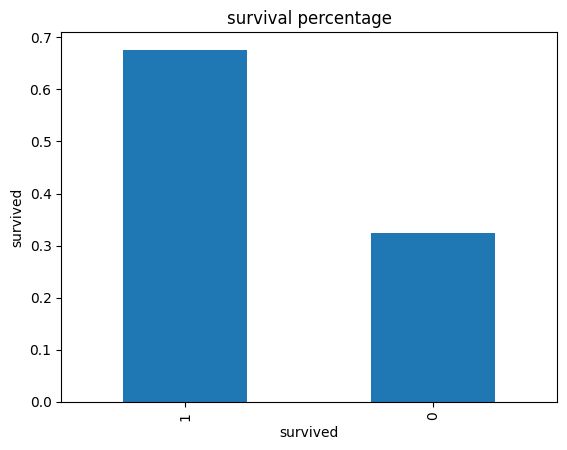

In [14]:
survival_rate = df["survived"].value_counts(normalize=True)
survival_rate.plot(kind="bar")
plt.title("survival percentage")
plt.ylabel("survived")
plt.show

Text(0.5, 1.0, 'survival')

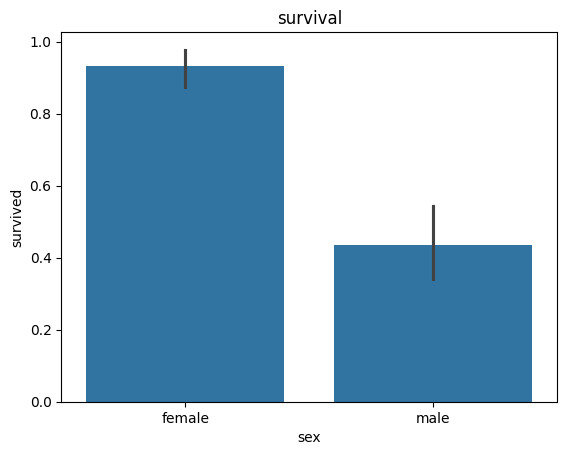

In [15]:
sns.barplot(x="sex",y="survived",data=df)
plt.title("survival")

In [16]:
#survival rate by gender: More females survived than male

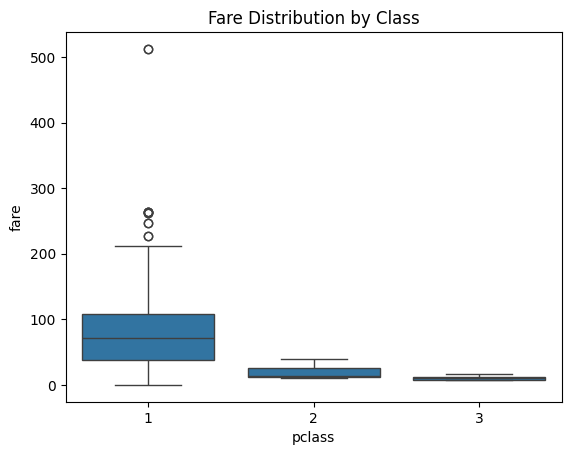

In [17]:
sns.boxplot(x="pclass",y="fare",data=df)
plt.title("Fare Distribution by Class")
plt.show()

In [18]:
#class 1 people paid more fare

<function matplotlib.pyplot.show(close=None, block=None)>

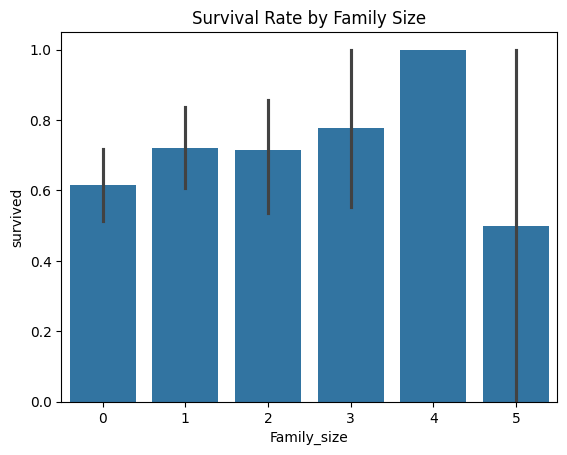

In [19]:
df['Family_size']=df["sibsp"]+ df["parch"]
sns.barplot(x="Family_size", y="survived",data=df)
plt.title("Survival Rate by Family Size")
plt.show
#the black line show that the data is unreliable: also known as error bars

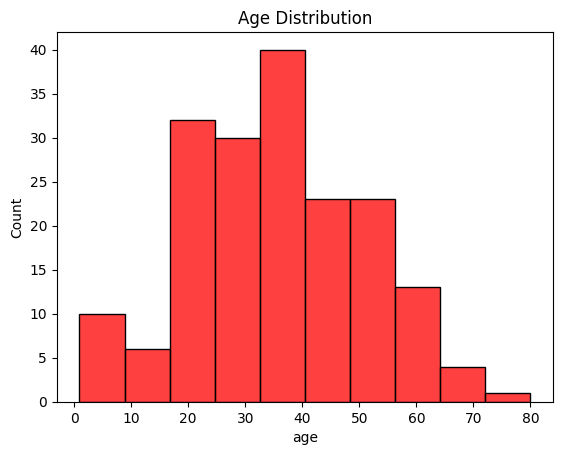

In [20]:
sns.histplot(df["age"],color="red")
plt.title("Age Distribution")
plt.show()

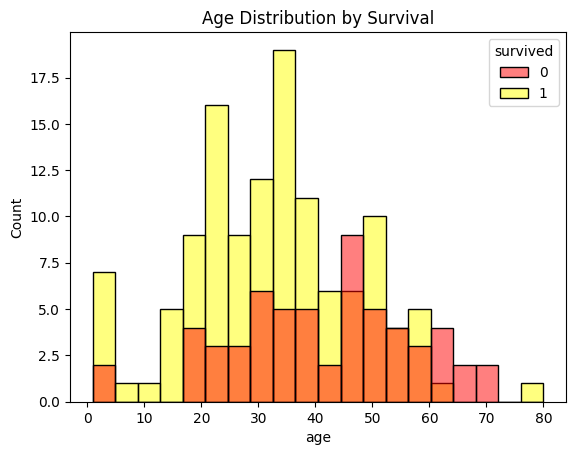

In [21]:
sns.histplot(data=df, x="age",hue="survived",palette=["red","yellow"],bins=20)
plt.title("Age Distribution by Survival")
plt.show()

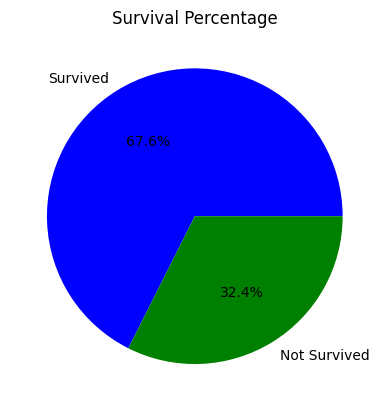

In [22]:
survival=df["survived"].value_counts()
plt.pie(survival,labels=["Survived","Not Survived"],autopct="%1.1f%%",colors=["blue","green"])
plt.title("Survival Percentage")
plt.show()

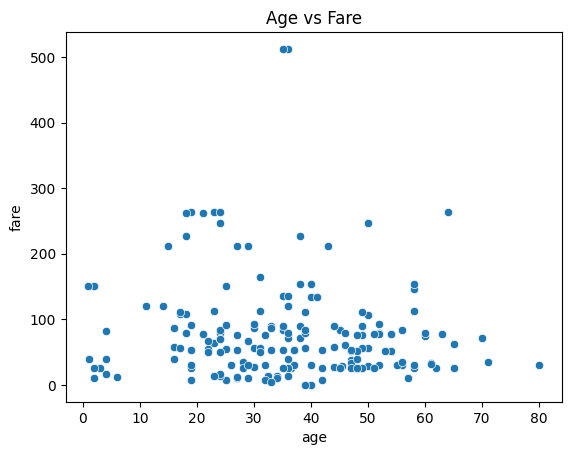

In [23]:
sns.scatterplot(x="age",y="fare",data=df)
plt.title("Age vs Fare")
plt.show()

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [25]:
df["embarked"].fillna('S',inplace=True)

/tmp/ipykernel_14652/344898261.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["embarked"].fillna('S',inplace=True)


In [26]:
df["deck"].fillna("unknown", inplace=True)

/tmp/ipykernel_14652/1777350503.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["deck"].fillna("unknown", inplace=True)


In [27]:
df.drop(["class", "who", "adult_male","deck","embark_town","alive"], axis=1, inplace=True)

In [28]:
df["sex"]=df["sex"].map({"male":0,"female":1})
df["embarked"]=df["embarked"].map({"S":0, "C":1, "Q":2})
df.drop("embarked", axis=1, inplace=True)
df["alone"]=df["alone"].map({True:1,False:0})
df.fillna(0,inplace=True)

In [29]:
x=df.drop("survived",axis=1)
y=df["survived"]

In [30]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [31]:
model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [32]:
y_pred=model.predict(x_test)

In [33]:
print(accuracy_score(y_test,y_pred))

0.6216216216216216


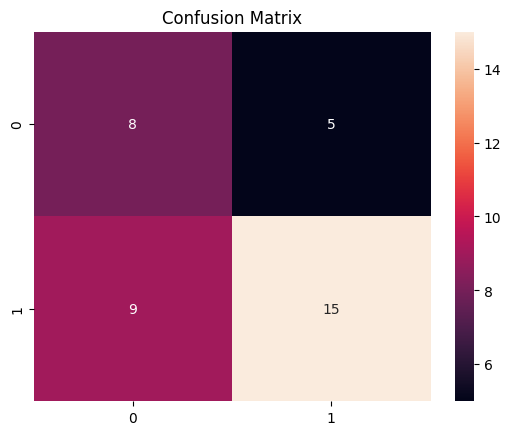

In [34]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt="d")
plt.title("Confusion Matrix")
plt.show()